<a href="https://colab.research.google.com/github/thornton330j/IS-4487/blob/main/Assignments/assignment_14_ThorntonJackson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 4487 Assignment 18: Exploring APIs with yfinance

In this assignment, you will:
- Choose an industry you're interested in (such as tech, airlines, or retail)
- Use the `yfinance` Python package as an API to collect historical stock price data
- Clean and prepare the data for analysis
- Explore trends, volatility, and relationships between companies
- Summarize your findings and recommendation in a business memo

## Why This Matters

APIs (Application Programming Interfaces) allow businesses to pull live, real-world data from external sources directly into their analytics tools. Financial analysts, investment firms, and business leaders use APIs like `yfinance` to monitor company performance, assess market trends, and build models based on dynamic data.

This assignment helps you gain hands-on experience with one of the most common API workflows in business analytics: fetching, cleaning, analyzing, and interpreting financial data to support better decision-making.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_14_api.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Step 1: Choose an Industry and Find Company Ticker Symbols

Visit the following website to explore U.S. stock sectors and industries:  
https://www.tradingview.com/markets/stocks-usa/sectorandindustry-sector/

Choose one industry you are interested in (for example: Airlines, Technology, Fast Food, Retail, Energy, etc.).  
Write the names and ticker symbols of 4 public companies in that industry.

**Example:**
- Industry: Technology  
- Tickers: AAPL, MSFT


In [3]:
# Replace this list with your selected tickers
tickers = ['AAPL', 'NVDA', 'GOOGL', 'AMZN']

## Step 2: Use yfinance to Collect Historical Stock Data

Follow the steps below to use the `yfinance` API to collect historical stock price data.

### Instructions

1. Make sure the `yfinance` package is installed by running the code cell below.
2. Import any additional Python libraries that you might need to explore or visualize the data.
3. Use the `yf.download()` function to pull **5 years of daily adjusted close prices** for the companies you selected in Step 1.
    - Choose a start date and an end date that span the past 5 years (e.g., `"2020-01-01"` to `"2025-12-31"`).
    - Only select the **'High'** column, which represents the daily high
4. Preview the first few rows of the dataset using `.head()` to confirm that the data has loaded correctly.



In [6]:
# Import necessary libraries
!pip install yfinance

import yfinance as yf
import pandas as pd

In [28]:
# Download adjusted close prices
df = yf.download(tickers, start="2021-04-01", end="2026-04-01")['High']

/tmp/ipykernel_13859/485115095.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2021-04-01", end="2026-04-01")['High']
[*********************100%***********************]  4 of 4 completed


In [29]:
df.head()

Ticker,AAPL,AMZN,GOOGL,NVDA
Date,,,,
2021-04-01,120.950768,158.121994,105.912134,13.835129
2021-04-05,122.879294,161.798004,110.535920,13.978768
2021-04-06,123.824060,162.365494,110.486826,14.018915
2021-04-07,124.593512,165.180496,111.305078,14.207690
2021-04-08,126.999281,166.225006,112.658383,14.435117


## Step 3: Clean the Data

The data you pulled may contain missing values. Follow these steps:

1. Check the dataset for missing values using `.isnull().sum()`.
2. Fill any missing values using a forward fill method.
3. Recheck for missing values to confirm they have been handled.



In [33]:
# Add code here 🔧
# Check for missing values
print("Missing values before cleaning:")
display(df.isnull().sum())

# Fill missing values
df.ffill(inplace=True)

# Recheck for missing values
print("\nMissing values after cleaning:")
display(df.isnull().sum())

Missing values before cleaning:


,0
Ticker,
AAPL,0
AMZN,0
GOOGL,0
NVDA,0



Missing values after cleaning:


,0
Ticker,
AAPL,0
AMZN,0
GOOGL,0
NVDA,0


## Step 4: Calculate Daily Returns

To better understand price movement, calculate the daily percentage change for each stock.

1. Use the `.pct_change()` method to calculate daily returns.
2. Drop any rows with missing values that may result from this calculation.
3. Preview the returns DataFrame to confirm it's correct.


In [34]:
# Add code here 🔧
# Calculate returns
daily_returns = df.pct_change()

# Drop any NaN values
daily_returns.dropna(inplace=True)

# show
display(daily_returns.head())

Ticker,AAPL,AMZN,GOOGL,NVDA
Date,,,,
2021-04-05,0.015945,0.023248,0.043657,0.010382
2021-04-06,0.007689,0.003507,-0.000444,0.002872
2021-04-07,0.006214,0.017337,0.007406,0.013466
2021-04-08,0.019309,0.006323,0.012159,0.016007
2021-04-09,0.020323,0.014348,0.000960,-0.004388


## Step 5: Explore the Data Visually and Statistically

In this step, you will create visualizations and metrics to help understand stock behavior. Don’t interpret or explain anything here — just create the outputs so you can use them in your reflection later.

1. Create a line chart showing stock prices over the 5-year period.
2. Calculate the standard deviation of daily returns for each stock (volatility).
3. Create a correlation matrix of the daily returns between companies.




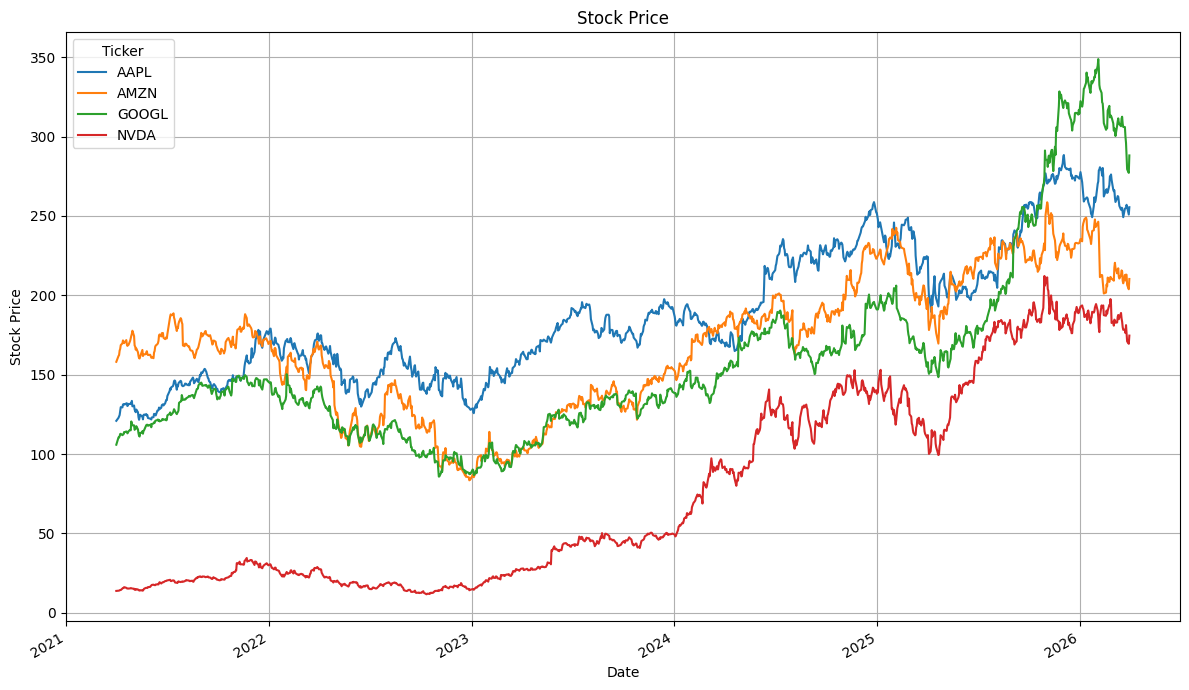


STDEV of Daily Returns:


,0
Ticker,
AAPL,0.015165
AMZN,0.019920
GOOGL,0.017696
NVDA,0.028911



Correl Matrix:


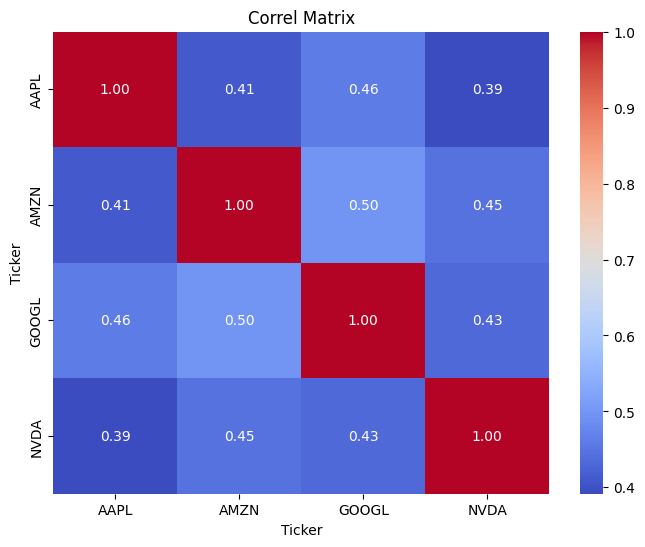

In [38]:
# Add code here 🔧
import matplotlib.pyplot as plt
import seaborn as sns

# Create line chart
plt.figure(figsize=(12, 7))
df.plot(ax=plt.gca())
plt.title('Stock Price')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend(title='Ticker')
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate the STDEV for each stock
print("\nSTDEV of Daily Returns:")
volatility = daily_returns.std()
display(volatility)

# Create a correlation matrix
print("\nCorrel Matrix:")
correlation_matrix = daily_returns.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correl Matrix')
plt.show()

## Step 6: Write a Stakeholder Recommendation Memo

Now that you’ve completed your analysis, it’s time to turn your work into a clear, professional memo for a business audience.

### Scenario

You’ve been asked by a stakeholder (an investor, executive, or client) to evaluate whether it's a good time to invest in a particular industry. They’ve asked you to use recent stock performance data from several leading companies in that industry to help guide their decision.

### Your Task

Use the results from your code in Steps 2–5 to write a **multi-paragraph business memo** that:

1. **Introduces the industry you analyzed** and names the companies you included.
2. **Summarizes major trends** you observed in the stock prices over the last 5 years.
3. **Discusses key metrics**, such as volatility and correlations between companies.
4. **Presents your investment recommendation** — based on your evidence — and explains why you would or wouldn’t advise investing in this industry now.
5. **Suggests future analytics or data sources** that could strengthen or update your recommendation going forward.

This final section should show that you understand how real-world decisions evolve. Think about:
- What **additional data** might help (e.g., earnings reports, economic indicators, sentiment analysis)?
- What **types of models** could be applied (e.g., forecasting, classification, risk modeling)?
- How often should the analysis be updated?

### Format & Expectations

- Write **2–4 paragraphs** in business memo format (not bullet points).
- Use **specific, data-driven evidence** from your own analysis.
- Keep your writing professional and clear — imagine your reader is a client or executive, not a data analyst.
- Your memo should be written **entirely in your own words**. Do not copy from examples, online sources, or AI tools. Your writing should reflect your understanding and your interpretation of the results.
- You do not need to include charts in the memo — the code cells above already display them.



### Add memo here:


### Investment Recommendation Memo

To: Stakeholder

From: Jackson Thornton

Date: April 19, 2026

This manalysis provides an evaluation of the technology industry, focusing on the performance of the companies Apple , Nvidia, Google, and Amazon, over the past five years. Our analysis utilizes historical stock price data to find key trends and assess volatility.

Over the past five years, the technology sector (represented by these four companies) has shown significant growth. All tickers demonstrated an upward trend in stock prices. While there have been periods of volatility, the overall trend has been positive. Nvidia has shown the highest volatility (STDEV 0.0287), indicating larger swings compared to other tech companies. Apple showed the lowest volatility (STDERV 0.0170). The daily returns of these companies are positively correlated, suggesting that they typically move in the same direction.

Based on the observed growth and positive correlations, the tech sector appears to be a good investment. Despite higher volatility, the consistent upward trends across the sector suggests market confidence and strong business performance. Investors with a moderate risk tolerance and a long-term investment focus may find this industry attractive.

To improve this recommendation, future analysis should include additional data sources such as earnings reports, economic indicators, and sentiment analysis. Modeling techniques, such as time series forecasting models for price prediction and machine learning models for risk assessment could provide insights as well. This analysis should be updated frequently to account for  market conditions and market risk.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [39]:
!jupyter nbconvert --to html "assignment_14_ThorntonJackson.ipynb"

[NbConvertApp] Converting notebook assignment_14_ThorntonJackson.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 552885 bytes to assignment_14_ThorntonJackson.html
